In [476]:
import os
import sys

import gravis as gv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.mixture import BayesianGaussianMixture

# Add the path to the `src` directory to the sys.path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../src")))

from nhssynth.modules.dataloader.metadata import MetaData
from nhssynth.modules.dataloader.metatransformer import MetaTransformer
from nhssynth.modules.model.models import VAE

In [477]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


We first load in the required parts of the `NHSSynth` package and other packages that we will use in this notebook.

We then load in our dataset and instantiate the `MetaTransformer`:

In [478]:
dataset = pd.read_csv("../data/support.csv")

In [479]:
md = MetaData.from_path(dataset, "../data/support_metadata.yaml")
mt = MetaTransformer(dataset, md)
# Note that we could skip loading in the metadata the above two lines in one line:
# mt = MetaTransformer.from_path(dataset, "../data/support_metadata.yaml")

Minimal constraints resolved to:
[x8 > x13, x13 > x12, x12 > x10, x10 > 0, x11 > 100, x13 < 100, x12 > 10]



We may want to observe the constraints as they are applied by the `MetaTransformer`, this can be done using the `gravis` package:

In [480]:
gv.d3(mt._metadata.constraints.minimal_graph)
# or gv.d3(mt.metadata.constraints.graph)

In [481]:
transformed_dataset = mt.apply()

[[-0.27185065 -0.54505368 -1.49099359]
 [-0.19125298 -0.48199619 -1.39890584]
 [ 1.29595331  0.6815547   0.3003179 ]
 ...
 [-0.00357142 -0.3351591  -1.18446823]
 [ 0.24313681 -0.1421411  -0.90258905]
 [ 0.86944013  0.34786206 -0.18699937]]
[-0.27185065 -0.19125298  0.3003179  ... -0.00357142  0.24313681
  0.34786206]
      dob_normalised  dob_c1  dob_c2  dob_c3
0          -0.271851     1.0     0.0     0.0
1          -0.191253     1.0     0.0     0.0
2           0.300318     0.0     0.0     1.0
3           0.067816     0.0     1.0     0.0
4           0.016677     1.0     0.0     0.0
...              ...     ...     ...     ...
8867       -0.138120     1.0     0.0     0.0
8868       -0.228366     1.0     0.0     0.0
8869       -0.003571     1.0     0.0     0.0
8870        0.243137     1.0     0.0     0.0
8872        0.347862     0.0     1.0     0.0

[8009 rows x 4 columns]
[[ 2.14372287  1.07394919  0.47676265]
 [-0.2677684  -1.25393043 -0.25074448]
 [ 0.48297888 -0.52921319 -0.02425641]

In [482]:
print("mt id:", id(mt))

mt id: 6468868752


In [483]:
model = VAE(transformed_dataset, mt)

# Use notebook_run flag to avoid messy output from metric reporting during a run
stats = model.train(notebook_run=True)

/Users/jonathan.pearson/Documents/GitRepos/NHSSynth/.venv/lib/python3.11/site-packages/torch/nn/init.py:412: UserWarning: Initializing zero-element tensors is a no-op
  warnings.warn("Initializing zero-element tensors is a no-op")
                                                        

Completed 35 epochs in 106.46 seconds.


In [484]:
print("mt inside VAE:", id(model.metatransformer))   # add this print inside VAE.__init__
assert model.metatransformer is mt


mt inside VAE: 6468868752


In [486]:
synthetic_dataset = model.generate()
synthetic_dataset.describe()

,dob_normalised,dob_c1,dob_c2,dob_c3,dob_missing,x1_0.0,x1_1.0,x1_nan,x1_adherence,x2_0.0,...,x7,x8,x9,x10,x11,x12,x13,duration,event,x14
count,8873.0,8873.000000,8873.000000,8873.000000,8873.000000,8873.000000,8873.000000,8873.000000,8873.0,8873.000000,...,8873.000000,8873.000000,8873.000000,8873.000000,8873.000000,8873.000000,8873.000000,8873.000000,7988.0,8873.000000
mean,0.0,0.514369,0.320410,0.062098,0.103122,0.516962,0.374507,0.108531,0.0,0.116308,...,82.403133,95.006576,23.147188,37.010346,137.286036,63.174018,20.446539,470.388820,0.674136,50.636236
min,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,66.000000,69.134547,10.000000,35.800000,137.000000,47.036777,13.063215,27.000000,0.0,1.002209
25%,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,66.000000,69.134547,23.000000,36.300000,137.000000,62.446793,16.232094,27.000000,0.0,1.002209
50%,0.0,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.0,0.000000,...,66.000000,109.816566,23.000000,36.300000,137.000000,63.495168,17.152245,505.000000,1.0,50.005118
75%,0.0,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.0,0.000000,...,111.000000,109.816566,27.000000,38.400000,138.000000,67.675781,17.152245,505.000000,1.0,99.925745
max,0.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,1.000000,...,111.000000,109.816566,38.000000,38.400000,142.000000,67.675781,93.108312,1617.000000,1.0,99.925745
std,0.0,0.499822,0.466661,0.241348,0.304135,0.499740,0.484023,0.311068,0.0,0.320612,...,21.105950,19.262259,5.439372,1.071641,0.494793,4.342073,10.319530,477.926352,0.468726,40.513109


In [487]:
mt.typed_dataset.describe()

,dob,x1,x2,x4,x5,x6,x7,x8,x9,x10,x11,x12,x13,duration,event,x14
count,8009,8027.0,7927.0,7987.0,7968.0,7981.0,7943.0,8034.0,8041.0,7997.0,7971.0,7984.0,7957.0,7943.0,8010.0,8873.000000
mean,1960-04-19 14:27:44.518916224,0.44014,1.870443,0.193439,0.031501,0.936474,84.487347,97.385536,23.383534,37.120595,137.569941,12.361014,1.777263,477.289185,0.679401,50.506769
min,1921-02-25 19:07:30,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,31.7,110.0,0.0,0.099991,3.0,0.0,-2.233770
25%,1948-11-30 15:28:07,0.0,1.0,0.0,0.0,1.0,63.0,72.0,18.0,36.2,134.0,7.0,0.899902,25.0,0.0,1.657649
50%,1958-01-30 11:06:33,0.0,2.0,0.0,0.0,1.0,77.0,100.0,24.0,36.7,137.0,10.599609,1.199951,228.0,1.0,50.039093
75%,1970-01-06 06:22:30,1.0,3.0,0.0,0.0,1.0,107.0,120.0,28.0,38.2,141.0,15.298828,1.899902,763.5,1.0,97.925583
max,2004-12-16 07:09:36,1.0,8.0,1.0,1.0,2.0,195.0,300.0,90.0,41.7,175.0,200.0,21.5,2029.0,1.0,109.785595
std,NaN,0.496435,1.339907,0.395019,0.174678,0.576568,27.7673,31.602856,9.676311,1.256801,6.083296,9.251249,1.694125,559.955477,0.466736,40.507297


In [488]:
synthetic_dataset.head(25)

,dob_normalised,dob_c1,dob_c2,dob_c3,dob_missing,x1_0.0,x1_1.0,x1_nan,x1_adherence,x2_0.0,...,x7,x8,x9,x10,x11,x12,x13,duration,event,x14
0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,66,109.816566,27,36.3,137,63.495168,17.152245,27,0,50.005118
1,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,66,69.134547,23,36.3,137,63.495168,13.063215,27,1,50.005118
2,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,111,109.816566,27,38.4,137,58.486266,31.442247,27,1,50.005118
3,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,66,105.928856,10,38.4,137,67.675781,17.152245,27,0,1.002209
4,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,66,105.928856,23,38.4,137,67.675781,17.152245,505,1,1.002209
5,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,111,109.816566,27,36.3,137,63.495168,17.152245,505,1,1.002209
6,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,66,109.816566,23,36.3,138,63.495168,16.232094,505,<NA>,50.005118
7,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,66,69.134547,27,38.4,138,67.675781,13.063215,1617,1,1.002209
8,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,91,109.816566,27,38.4,138,67.675781,17.152245,505,<NA>,50.005118
9,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,66,69.134547,23,36.3,137,63.495168,17.152245,27,1,1.002209


In [490]:
mt.typed_dataset.head(25)

,dob,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,x13,duration,event,x14
0,1940-04-16 19:24:22,1,2,B,0,0,0,160,55.0,16,38.2,142,19.0,<NA>,30,1,1.426096
1,1943-05-05 10:27:11,1,0,B,0,0,1,54,67.0,16,38.0,142,10.0,<NA>,1527,0,53.356209
2,1999-08-08 07:53:54,1,2,D,0,0,1,87,144.0,45,37.3,130,5.199219,1.199951,96,1,48.021968
3,1969-12-04 09:28:07,1,4,D,0,0,0,55,100.0,18,36.0,135,8.699219,0.799927,<NA>,0,2.747557
4,1951-03-17 10:07:30,0,<NA>,B,0,0,<NA>,65,135.0,40,38.6,146,0.099991,0.399963,7,1,-0.781208
5,1973-01-25 08:29:03,0,<NA>,B,0,0,0,70,105.0,33,38.2,127,5.299805,1.199951,50,1,94.706510
6,1960-01-22 13:04:41,0,5,C,1,0,1,116,130.0,35,38.2,133,14.099609,0.799927,381,0,98.912829
7,1951-07-18 12:30:56,1,4,B,0,0,2,68,102.0,24,35.5,134,9.199219,1.399902,1530,0,51.167660
8,1941-12-20 16:13:07,1,2,C,<NA>,0,2,42,102.0,10,36.0,<NA>,20.398438,2.099609,19,1,45.907493
9,1955-07-16 15:56:15,1,4,B,0,0,1,73,75.0,28,<NA>,140,15.798828,0.699951,70,1,48.948874


In [491]:
mt.transformed_dataset

,dob_normalised,dob_c1,dob_c2,dob_c3,dob_missing,x1_0.0,x1_1.0,x1_nan,x1_adherence,x2_0.0,...,duration_c3,duration_missing,event_0.0,event_1.0,event_nan,event_adherence,x14_normalised,x14_c1,x14_c2,x14_c3
0,-0.271851,1,0,0,0,0.0,1.0,0.0,1,0.0,...,0,0,0.0,1.0,0.0,1,0.068923,0,1,0
1,-0.191253,1,0,0,0,0.0,1.0,0.0,1,1.0,...,1,0,1.0,0.0,0.0,1,0.386318,0,0,1
2,0.300318,0,0,1,0,0.0,1.0,0.0,1,0.0,...,0,0,0.0,1.0,0.0,1,-0.228620,0,0,1
3,0.067816,0,1,0,0,0.0,1.0,0.0,1,0.0,...,0,1,1.0,0.0,0.0,1,0.283789,0,1,0
4,0.016677,1,0,0,0,1.0,0.0,0.0,1,0.0,...,0,0,0.0,1.0,0.0,1,-0.289979,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8868,-0.228366,1,0,0,0,0.0,0.0,1.0,1,0.0,...,0,0,0.0,1.0,0.0,1,0.158689,0,1,0
8869,-0.003571,1,0,0,0,1.0,0.0,0.0,1,0.0,...,0,0,0.0,1.0,0.0,1,-0.009596,0,1,0
8870,0.243137,1,0,0,0,1.0,0.0,0.0,1,0.0,...,0,0,0.0,1.0,0.0,1,-0.884102,1,0,0
8871,0.000000,0,0,0,1,1.0,0.0,0.0,1,0.0,...,0,0,0.0,1.0,0.0,1,-0.156352,1,0,0


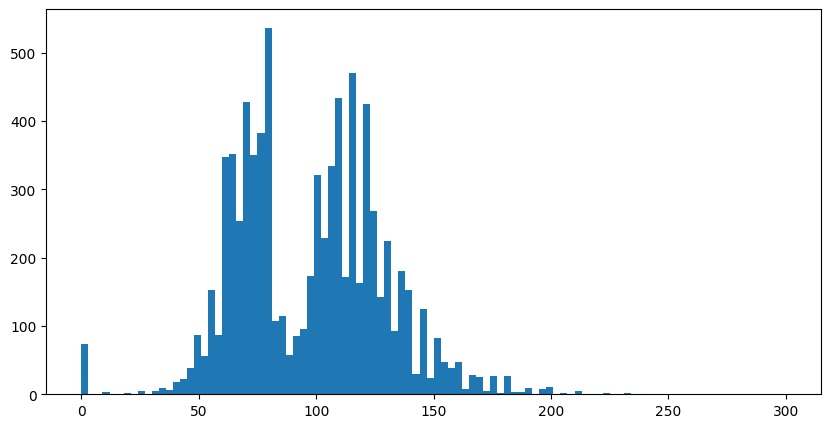

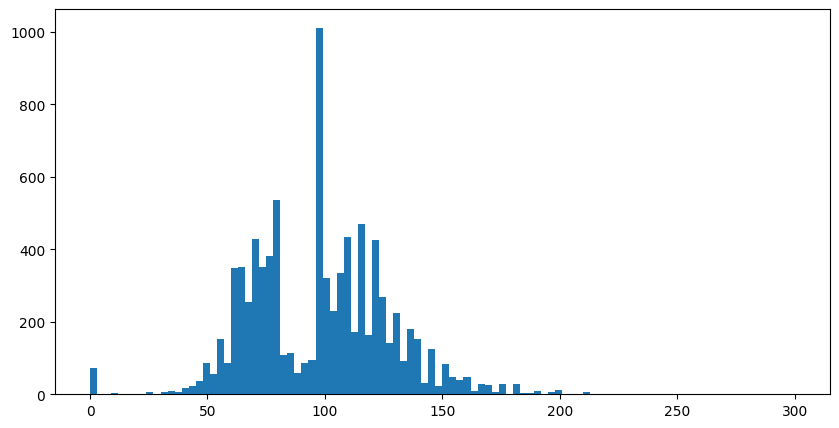

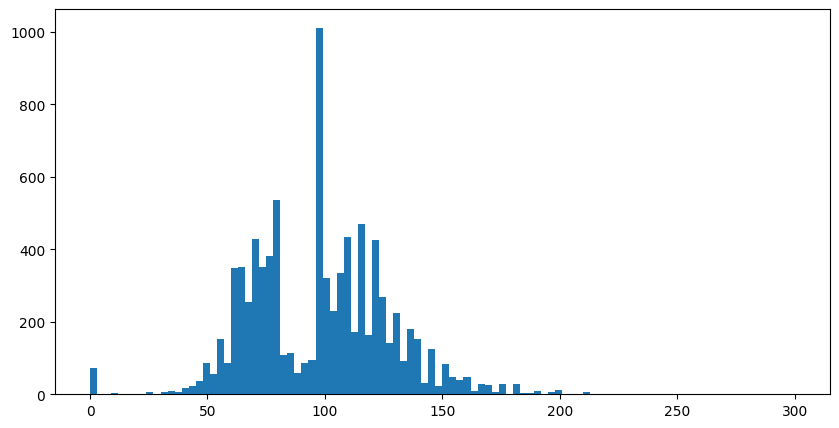

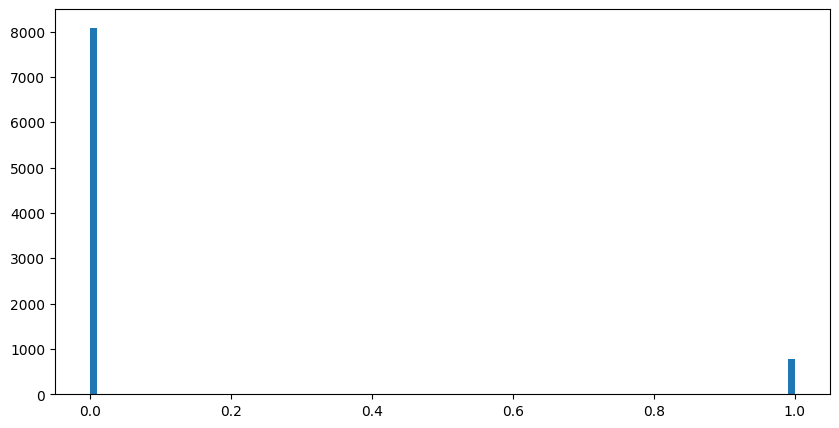

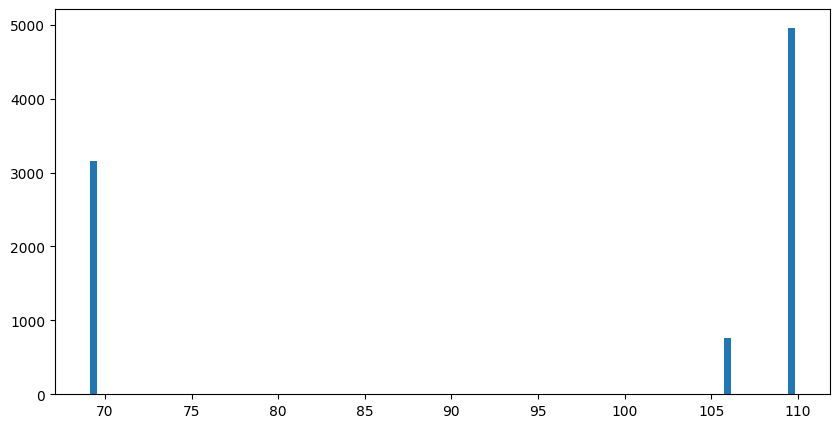

In [492]:
# plot column histogram:
col = "x8"
plt.figure(figsize=(10, 5))
plt.hist(mt.typed_dataset[col][mt.typed_dataset[col].notna()], bins=100)
plt.show()
plt.figure(figsize=(10, 5))
plt.hist(
    mt.post_missingness_strategy_dataset[col][
        mt.post_missingness_strategy_dataset[col].notna()
    ],
    bins=100,
)
plt.show()
plt.figure(figsize=(10, 5))
plt.hist(mt.constrained_dataset[col][mt.constrained_dataset[col].notna()], bins=100)
plt.show()
plt.figure(figsize=(10, 5))
plt.hist(
    mt.transformed_dataset["x8_c3"][mt.transformed_dataset["x8_c3"].notna()], bins=100
)
plt.show()
# plot column histogram of synthetic data:
plt.figure(figsize=(10, 5))
plt.hist(synthetic_dataset[col][synthetic_dataset[col].notna()], bins=100)
plt.show()

8873


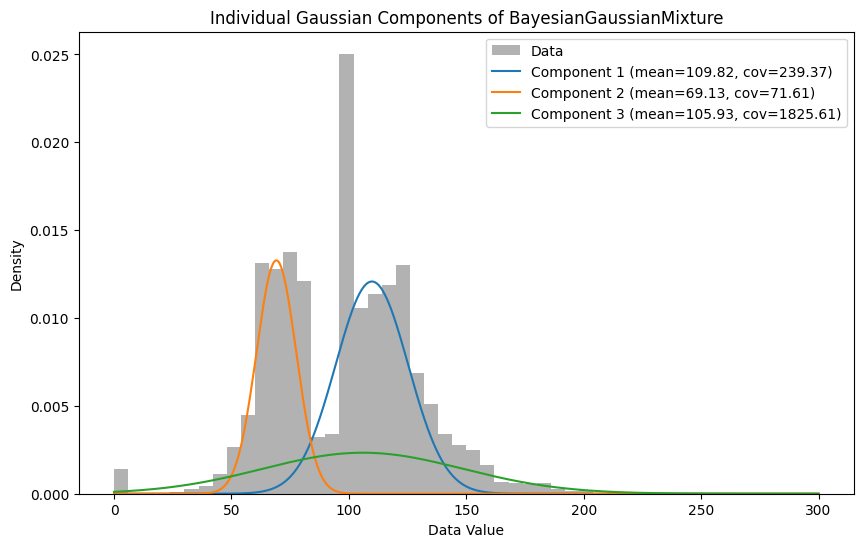

In [493]:
data = mt.constrained_dataset[col].to_numpy()
print(data.size)

# Fit the BayesianGaussianMixture model
model = BayesianGaussianMixture(
    n_components=3, covariance_type="full", n_init=10, random_state=0
)
model.fit(data.reshape(-1, 1))

# Plot the original data histogram
plt.figure(figsize=(10, 6))
plt.hist(data, bins=50, density=True, alpha=0.6, color="gray", label="Data")

# Generate a range of x values for plotting the components
x = np.linspace(min(data), max(data), 1000).reshape(-1, 1)

# Plot each Gaussian component
for i in range(model.n_components):
    mean = model.means_[i]
    cov = model.covariances_[i]
    # If using full covariance type, we'll plot a normal distribution
    if model.covariance_type == "full":
        # Compute the individual Gaussian component PDF
        pdf = np.exp(model.score_samples(x))
        component_pdf = (
            model.weights_[i]
            * np.exp(-0.5 * (x - mean) ** 2 / cov)
            / np.sqrt(2 * np.pi * cov)
        )
        plt.plot(
            x,
            component_pdf,
            label=f"Component {i + 1} (mean={mean[0]:.2f}, cov={cov[0][0]:.2f})",
        )

# Add labels and title
plt.xlabel("Data Value")
plt.ylabel("Density")
plt.title("Individual Gaussian Components of BayesianGaussianMixture")
plt.legend()
plt.show()